# <span style="color:red"><center>Construcción automática de texto </center></span>

<center>Introducción</center>

<figure>
<center>
<img src="../Imagenes/text_generation_sampling.png" width="800" height="600" align="center"/>
</center>
<figcaption>
<p style="text-align:center">Muestreo  de palabras</p>
</figcaption>
</figure>

Fuente: [Text generation with an RNN](https://www.tensorflow.org/tutorials/text/text_generation)

##   <span style="color:blue">Referencias</span>

1. Basado en el blog de laurencemoroney: (https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sonnets.txt)

##   <span style="color:blue">Contenido</span>

* [Introducción](#Introducción)
* [Datos](#Datos)
* [Preprocesamiento](#Preprocesamiento)
* [Librerías](#Librerías)
* [Lee los datos](#Lee-los-datos)
* [Tokeniza el texto](#Lee-los-datos)
* [Crea n-Grams para datos de entrenamiento y etiquetas](#Crea-n-Grams-para-datos-de-entrenamiento-y-etiquetas)
* [Crea-el-modelo](#Crea-el-modelo)
* [Genera-texto-automáticamente](#Genera-texto-automáticamente)

In [1]:
import tensorflow as tf
print(tf.__version__)

# !pip install -q tensorflow-datasets

2.13.0


In [3]:
!pip install tensorflow

In [3]:
#pip install --upgrade tensorflow

In [4]:
#!pip3 install "numpy<2.0.0"

##   <span style="color:blue">Introducción</span>

Gran conjunto de datos basado en sonetos de Shekespeare.


##   <span style="color:blue">Librerías</span>


In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
import numpy as np 
from tensorflow.keras.models import load_model

from tensorflow.keras.utils import plot_model

## <span style="color:blue">Lee los datos</span>

In [26]:
#!wget --no-check-certificate \
#    https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sonnets.txt \
#    -O /tmp/sonnets.txt
data = open('../Datos/sonnets.txt').read()

corpus = data.lower().split("\n")

## <span style="color:blue">Tokeniza el texto</span>


In [27]:
tokenizer = Tokenizer()

corpus = data.lower().split("\n")
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

#print('Dictionary: ',tokenizer.word_index,'\n')
print('índice de creatures = ',tokenizer.word_index['creatures'])
print('\nTNúmero total d palabras en el Tokenizador (+OOV) =',total_words,'\n')

# Muestra parte del corpus
print('Primeras líneas del corpus: \n')
corpus[0:10]

índice de creatures =  881

TNúmero total d palabras en el Tokenizador (+OOV) = 3375 

Primeras líneas del corpus: 



['\tsonnets',
 '',
 '',
 '',
 'to the only begetter of',
 'these insuing sonnets',
 'mr. w. h. all happiness',
 'and that eternity',
 'promised by',
 'our ever-living poet wisheth']

## <span style="color:blue">Crea n-Grams para datos de entrenamiento y etiquetas</span>


In [28]:
# crear secuencias de entrada usando una lista de tokens
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)
        
print('input_sequences[0:10] = ',input_sequences[:10],'\n')

# Determine el n-gram más largo
max_seq_test_len = max([len(x) for x in input_sequences])
print('\nlongitud del  n-grama más largo:',max_seq_test_len)


input_sequences[0:10] =  [[3, 2], [3, 2, 313], [3, 2, 313, 1375], [3, 2, 313, 1375, 4], [118, 1376], [118, 1376, 878], [1377, 1378], [1377, 1378, 1379], [1377, 1378, 1379, 23], [1377, 1378, 1379, 23, 1380]] 


longitud del  n-grama más largo: 11


### ¿Qué hizo tokenizer?

In [32]:
line = corpus[0]
token_list = tokenizer.texts_to_sequences([line])
print(line)
print(token_list)
print(token_list[0])

	sonnets
[[878]]
[878]


### Agrega PAD para tener secuencias de la misma longitud

In [33]:
# pad sequences 
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# crea predictores y etiqueta
predictors, label = input_sequences[:,:-1],input_sequences[:,-1]

#

In [34]:
print(input_sequences.shape)
print(predictors.shape)
print(label.shape)

(15484, 11)
(15484, 10)
(15484,)


In [35]:
print(len(predictors))
print(len(label))

15484
15484


In [12]:
print(input_sequences[0:3]) # secuencia completa
print('\n')
print(predictors[0:3]) # secuencia hasta el anterior al último
print('\n')
print(label[0:3]) # el último de la secuencia

[[   0    0    0    0    0    0    0    0    0    3    2]
 [   0    0    0    0    0    0    0    0    3    2  313]
 [   0    0    0    0    0    0    0    3    2  313 1375]]


[[  0   0   0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   0   0   0   3   2]
 [  0   0   0   0   0   0   0   3   2 313]]


[   2  313 1375]


# Convierte etiquetas a 1-hot

If label = [1, 0, 2] and total_words = 4, the output becomes:

[[0, 1, 0, 0],

 [1, 0, 0, 0],
 
 [0, 0, 1, 0]]

In [36]:
label = to_categorical(label, num_classes=total_words)
print(label.shape)

(15484, 3375)


<figure>
<center>
<img src="../Imagenes/bidirectiona_LSTM.png" width="700" height="500" align="center"/>
</center>
<figcaption>
<p style="text-align:center">Bidirectional LSTM</p>
</figcaption>
</figure>


<figure>
<center>
<img src="../Imagenes/dropout-keras.png" width="500" height="400" align="center"/>
</center>
<figcaption>
<p style="text-align:center">Dropout Layer</p>
</figcaption>
</figure>


<figure>
<center>
<img src="../Imagenes/bi_LSTM.png" width="800" height="600" align="center"/>
</center>
<figcaption>
<p style="text-align:center">Modelo RNN Ejemplo</p>
</figcaption>
</figure>


## <span style="color:blue">Crea el modelo</span>

In [37]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
#This line adds a bidirectional LSTM layer to the model with 150 units and return_sequences=True. 
#The bidirectional layer processes the input sequence in both forward and backward directions.
model.add(Bidirectional(LSTM(150, return_sequences = True)))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(total_words/2, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 10, 100)           337500    
                                                                 
 bidirectional_1 (Bidirecti  (None, 10, 300)           301200    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 10, 300)           0         
                                                                 
 lstm_3 (LSTM)               (None, 100)               160400    
                                                                 
 dense_2 (Dense)             (None, 1687)              170387    
                                                                 
 dense_3 (Dense)             (None, 3375)              5697000   
                                                      

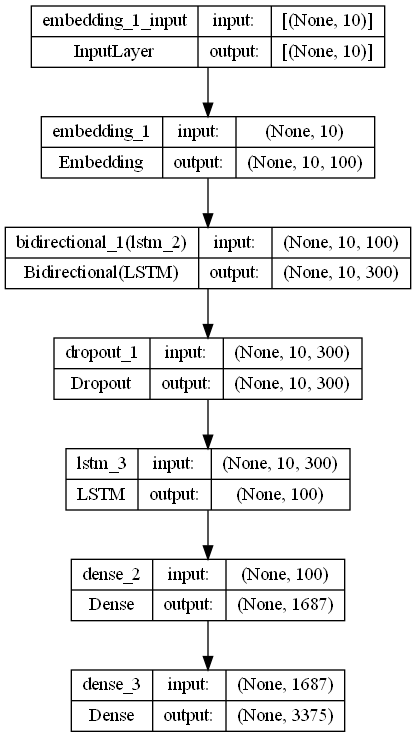

In [38]:
print(model.summary())
plot_model(model, to_file='../Imagenes/sonetos.png', 
           show_shapes=True)

## <span style="color:blue">Entrena</span>

In [24]:
 history = model.fit(predictors, label, epochs=10, verbose=1)

Epoch 1/10
484/484 [==============================] - 83s 143ms/step - loss: 1.1192 - accuracy: 0.8020
Epoch 2/10
484/484 [==============================] - 67s 139ms/step - loss: 1.0703 - accuracy: 0.8135
Epoch 3/10
484/484 [==============================] - 65s 134ms/step - loss: 1.0611 - accuracy: 0.8113
Epoch 4/10
484/484 [==============================] - 76s 157ms/step - loss: 1.0514 - accuracy: 0.8143
Epoch 5/10
484/484 [==============================] - 94s 194ms/step - loss: 1.0470 - accuracy: 0.8154
Epoch 6/10
484/484 [==============================] - 100s 206ms/step - loss: 1.0326 - accuracy: 0.8185
Epoch 7/10
484/484 [==============================] - 82s 169ms/step - loss: 1.0465 - accuracy: 0.8133
Epoch 8/10
484/484 [==============================] - 95s 196ms/step - loss: 1.0374 - accuracy: 0.8126
Epoch 9/10
484/484 [==============================] - 90s 186ms/step - loss: 1.0259 - accuracy: 0.8176
Epoch 10/10
484/484 [==============================] - 82s 170ms/step - 

# embedding of the vocabulary

In [42]:
# Get the embedding layer from the model (first layer)
embedding_layer = model.layers[0]

# Get the embedding weights: shape (total_words, embedding_dim=100)
embedding_weights = embedding_layer.get_weights()[0]   # returns a numpy array

# Retrieve the index of the word 'creature' from the tokenizer
word_index = tokenizer.word_index   # dict: word -> integer index
creature_index = word_index.get('sonnets')

if creature_index is not None:
    # Extract the embedding vector (the row corresponding to that index)
    creature_embedding = embedding_weights[creature_index]
    print(f"Embedding vector for 'sonnets' (shape: {creature_embedding.shape}):")
    print(creature_embedding)
else:
    print("The word 'sonnets' is not in the vocabulary.")

Embedding vector for 'sonnets' (shape: (100,)):
[ 0.04514102  0.04615228 -0.03246401 -0.03570331  0.04918041 -0.00860628
  0.04894451 -0.00657582  0.01581476  0.011503   -0.01421412  0.03867251
 -0.01296846  0.03638014  0.03274392 -0.00194154 -0.00925518 -0.02782792
 -0.02608081 -0.00595636  0.02006528  0.00418254  0.04838755 -0.04898122
  0.00811961  0.01886545 -0.0471058  -0.02226055 -0.03679099 -0.0414636
  0.02714631  0.04685675  0.02210934 -0.02703018  0.04862786 -0.0255418
 -0.02439473 -0.02117554 -0.01154562 -0.04693476  0.02292236  0.0381799
 -0.00527463 -0.0459149   0.0482275   0.02481658 -0.01959864 -0.03023906
  0.02712414 -0.00715579  0.04247111 -0.00690385  0.02534306  0.00733785
  0.04002405  0.01443869 -0.01746286  0.01676086 -0.03633752  0.00310016
  0.00032405 -0.02387054  0.0156096   0.02570299 -0.01442031  0.00705936
  0.00748444  0.02263082 -0.00530954 -0.03995734 -0.04829044 -0.03846573
 -0.03771118 -0.02244409  0.01337203  0.03060926  0.0237061   0.01523509
 -0.02

In [18]:
model.save("../Saved_Models/rnn_2")

INFO:tensorflow:Assets written to: ../Saved_Models/rnn_2\assets


INFO:tensorflow:Assets written to: ../Saved_Models/rnn_2\assets


In [43]:
model = load_model("../Saved_Models/rnn_1")

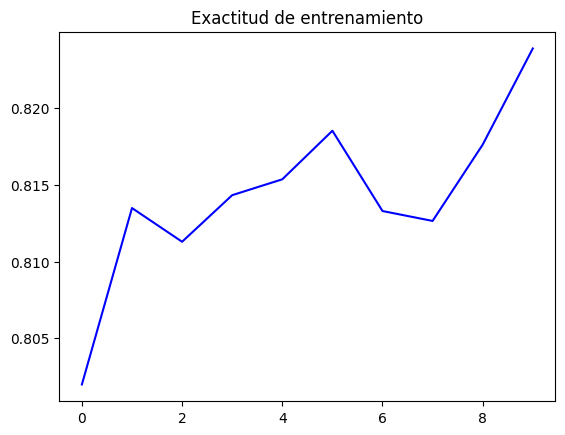

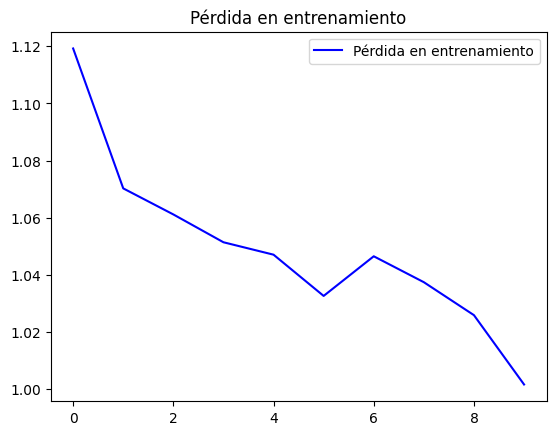

In [44]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Exactitud de entrenamiento')

plt.title('Exactitud de entrenamiento')

plt.figure()

plt.plot(epochs, loss, 'b', label='Pérdida en entrenamiento')
plt.title('Pérdida en entrenamiento')
plt.legend()

plt.show()

## <span style="color:blue">Genera texto automáticamente</span>

In [45]:
seed_text = "I want to say Hello!"
next_words = 100
  
for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    #predicted = model.predict_classes(token_list, verbose=0)
    #predicted = (model.predict(token_list) > 0.5).astype("int32")
    predicted = np.argmax(model.predict(token_list), axis=-1) 
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break
    seed_text += " " + output_word
print(seed_text)

1/1 [==============================] - 0s 73ms/step
I want to say Hello! as power and nothing nothing green green green love hate back none parts to taste of far hate part words seen life leaves convert pity tend bearing thine eyes lose forth slain bright prove seen old friend free bearing thine eye ' ' lies room old grave eyes flatter die give down good lease greater friend eyes live dear substance words was true mine eyes bold not prove thy eyes skill skill bearing thine ' mayst forth free dearer heart lies prove young her friend slain forth seen seen green none forth gone old friend again are forth lease old
